# Image Compression using Modulo-Compressive Sensing

## Importing Libraries and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.transform
import time
from optimization.milp import solve_modulo_cs_milp

## Data Exploration

In [2]:
# load csv data to a numpy array
# train_data = np.loadtxt('data/mnist_train.csv', delimiter=',')
test_data = np.loadtxt('data/mnist_test.csv', delimiter=',')

In [3]:
test_data.shape

(10000, 785)

## Generating CS Matrix

In [4]:
def generate_CS_matrix(M:int, N:int):
    # Generate M x N matrix from standard Gaussian
    A = np.random.randn(M, N)

    # Normalize COLUMNS (axis=0) to unit l2 norm
    A = A / np.linalg.norm(A, ord=2, axis=0)

    return A

## Generating Measurements

In [5]:
def generate_measurements(image_data: np.ndarray, num_measurements: int) -> tuple[np.ndarray, np.ndarray]:
    """
        Generate modulo measurements y = [[Ax]], where [[]] denotes the fractional parts of the elements of the vector Ax
        
        Parameters:
            - image_data: np.ndarray flattened vector of the image pixel values
            - num_measurements: int number of samples to be acquired of the 'densified' sparse image

        Returns:
            - np.ndarray: acquired samples y
            - np.ndarray: 2D compressed-sensing matrix    
    """
    
    num_pixels = len(image_data)
    # generating a normalized Gaussian-distributed Compressed Sensing Matrix
    A = generate_CS_matrix(M=num_measurements, N=num_pixels) # M < N
    # acquiring dense modulo samples from the sparse image vector
    y_dense = A @ image_data
    y = y_dense - np.floor(y_dense)

    return y, A

## Sparse Image Recovery

### Rescale image

In [10]:
pixel_width = 14
image_index = 18 # works: 91, 2   doesn't work: 1052, 55, 1, 3
# 1. Strip the label (index 0) and grab only the 784 pixels
raw_pixels = test_data[image_index, 1:]

# 2. Reshape to 28x28 and scale to [0, 1]
img_2d = raw_pixels.reshape(28, 28) / 255.0

# 3. Downsample to 14x14 (N=196) to make the MILP problem mathematically feasible
img_small = skimage.transform.resize(img_2d, (pixel_width, pixel_width), anti_aliasing=True)
# Force tiny values to zero to restore sparsity
img_small[img_small < 0.2] = 0.0
raw_image_small = img_small.flatten()
# 4. Flatten back to a 1D vector (length 196)
raw_image_small = img_small.flatten()

### MILP

In [11]:
# Generate measurements using the much smaller, properly processed image
y, A = generate_measurements(image_data=raw_image_small, num_measurements=100)

In [12]:
# Run the solver (v_bound=10 is safe since the image is scaled [0,1])
start_time = time.perf_counter()
x_reconst, integer_part, res = solve_modulo_cs_milp(A, y, v_bound=6, mip_rel_gap=0.7)
end_time = time.perf_counter()

# Post-process and plot (remember the reconstructed image is now 14x14)
reconstructed_scaled = np.clip(x_reconst, 0.0, 1.0) * 255.0
img_reconstructed = reconstructed_scaled.reshape(pixel_width, pixel_width)

 Mean Squared Error (MSE): 7742.9317
 Running time (s): 264.1017


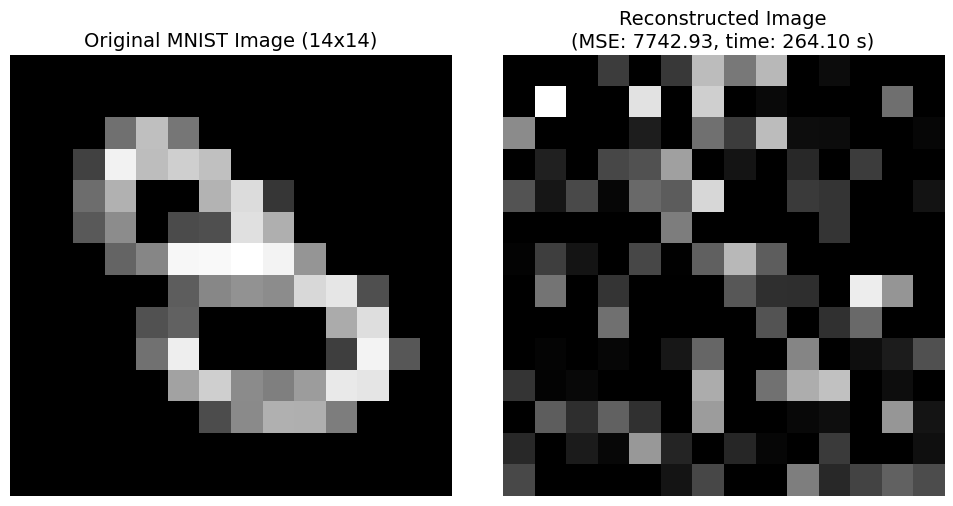

In [13]:
# 3. Define original_scaled to match the 0-255 scale of reconstructed_scaled
original_scaled = raw_image_small * 255.0
mse = np.mean((original_scaled - reconstructed_scaled) ** 2)

print(f"=====================================")
print(f" Mean Squared Error (MSE): {mse:.4f}")
print(f"=====================================")

print(f"=====================================")
print(f" Running time (s): {end_time-start_time:.4f}")
print(f"=====================================")
# 4. Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image Plot (Using the 14x14 downsampled image 'img_small')
axes[0].imshow(img_small, cmap='gray')
axes[0].set_title("Original MNIST Image (14x14)", fontsize=14)
axes[0].axis('off')

# Reconstructed Image Plot
axes[1].imshow(img_reconstructed, cmap='gray')
axes[1].set_title(f"Reconstructed Image\n(MSE: {mse:.2f}, time: {end_time-start_time:.2f} s)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()

# plt.savefig("reconstruction14x14_1.png", dpi=300)
plt.show()

### Graph of performance vs number of transmissions

Beginning MILP evaluation across 7 target images.
Target Indices: [91, 2, 5, 14, 824, 741, 18]

Evaluating M =  40... Done! [Avg Time:  0.03s | Avg NMSE: 1.24e+00]
Evaluating M =  60... Done! [Avg Time:  0.30s | Avg NMSE: 1.36e+00]
Evaluating M =  80... Done! [Avg Time:  1.14s | Avg NMSE: 9.22e-01]
Evaluating M = 100... Done! [Avg Time:  4.21s | Avg NMSE: 9.65e-01]

All simulations completed! Constructing average metric performance trends...


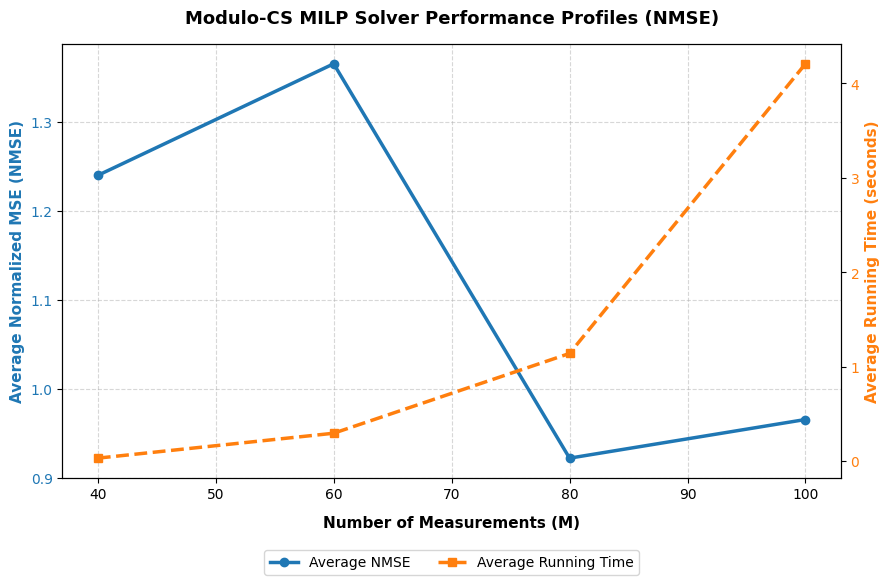

In [17]:
# =====================================================================
# 1. USER INPUT: DEFINE YOUR TEST IMAGE INDEXES HERE
# =====================================================================
# You can add as many or as few indices from test_data as you like:
selected_indices = [91, 2, 5, 14, 824, 741, 18]

# Define the range of measurements (M) to sweep over
M_values = [40, 60, 80, 100] # , 200, 250, 300, 350, 400]

# Arrays to store the calculated averages per M
avg_milp_nmses = []
avg_milp_times = []

print(f"Beginning MILP evaluation across {len(selected_indices)} target images.")
print(f"Target Indices: {selected_indices}\n")

# =====================================================================
# 2. RUN EVALUATION LOOP
# =====================================================================
for M in M_values:
    print(f"Evaluating M = {M:3d}...", end=" ", flush=True)

    # Storage arrays to track metrics for individual images at the current M value
    current_m_nmses = []
    current_m_times = []

    for idx in selected_indices:
        # Step A: Extract, normalize, and downsample the specific image
        raw_pixels = test_data[idx, 1:]
        img_2d = raw_pixels.reshape(28, 28) / 255.0
        img_small = skimage.transform.resize(img_2d, (14, 14), anti_aliasing=True)
        raw_image_small = img_small.flatten()
        N = len(raw_image_small)  # 196

        # Step B: Generate specific CS matrix and modulo wraps
        A = generate_CS_matrix(M=M, N=N)
        y_linear = A @ raw_image_small
        y_modulo = y_linear - np.floor(y_linear)

        # Step C: Profile MILP Execution Speed
        start_time = time.perf_counter()
        x_milp, _, res = solve_modulo_cs_milp(A, y_modulo, v_bound=4, mip_rel_gap=0.8)
        end_time = time.perf_counter()

        # Safety fallback if the solver terminates without finding a solution
        if x_milp is None:
            x_milp = np.zeros_like(raw_image_small)

        # Step D: Profile Signal Reconstruction Error using NMSE
        x_milp_clipped = np.clip(x_milp, 0.0, 1.0)

        # NMSE calculation: sum of squared errors divided by sum of true squared values
        squared_error = np.sum((raw_image_small - x_milp_clipped) ** 2)
        signal_energy = np.sum(raw_image_small ** 2)

        # Guard against rare division-by-zero for completely blank black images
        nmse = squared_error / signal_energy if signal_energy > 0 else squared_error

        # Log individual image statistics
        current_m_nmses.append(nmse)
        current_m_times.append(end_time - start_time)

    # Step E: Compute final averages for the current measurement size M
    avg_nmse_at_m = np.mean(current_m_nmses)
    avg_time_at_m = np.mean(current_m_times)

    avg_milp_nmses.append(avg_nmse_at_m)
    avg_milp_times.append(avg_time_at_m)

    print(f"Done! [Avg Time: {avg_time_at_m:5.2f}s | Avg NMSE: {avg_nmse_at_m:.2e}]")

print("\nAll simulations completed! Constructing average metric performance trends...")

# =====================================================================
# 3. PLOT PERFORMANCE GRAPH (SINGLE CHART, TWIN Y-AXES, LINEAR SCALE)
# =====================================================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Define colors to match your reference layout
color_nmse = '#1f77b4'   # Blue
color_time = '#ff7f0e'  # Orange

# --- Left Axis: Normalized Mean Squared Error ---
ax1.set_xlabel('Number of Measurements (M)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Average Normalized MSE (NMSE)', color=color_nmse, fontsize=11, fontweight='bold')
line1 = ax1.plot(M_values, avg_milp_nmses, color=color_nmse, marker='o', linewidth=2.5, label='Average NMSE')
ax1.tick_params(axis='y', labelcolor=color_nmse)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Right Axis: Running Time (Twin Axis Share-X) ---
ax2 = ax1.twinx()
ax2.set_ylabel('Average Running Time (seconds)', color=color_time, fontsize=11, fontweight='bold')
line2 = ax2.plot(M_values, avg_milp_times, color=color_time, marker='s', linewidth=2.5, linestyle='--', label='Average Running Time')
ax2.tick_params(axis='y', labelcolor=color_time)

# --- Set Linear Scale Explicitly ---
ax1.set_yscale('linear')
ax2.set_yscale('linear')

# --- Combine Legends into One Frame ---
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fontsize=10)

plt.title(f"Modulo-CS MILP Solver Performance Profiles (NMSE)",
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()